<a href="https://colab.research.google.com/github/siddhant216/CODSOFT/blob/main/SALES_PREDICTION_USING_PYTHON_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/advertising.csv")
print(df.head())


      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


In [ ]:
print(df.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


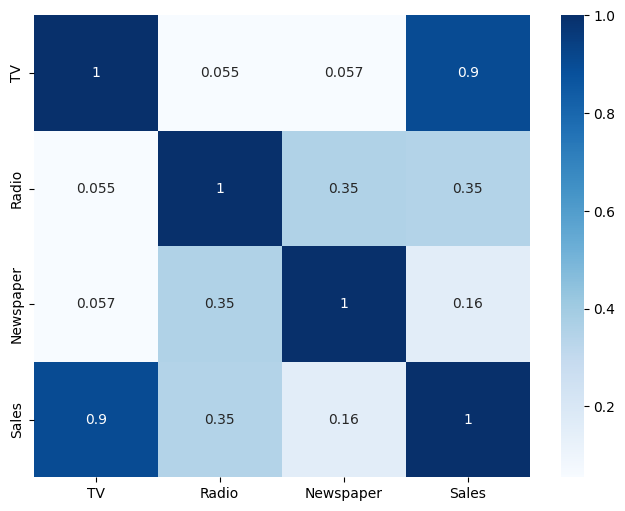

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.show()

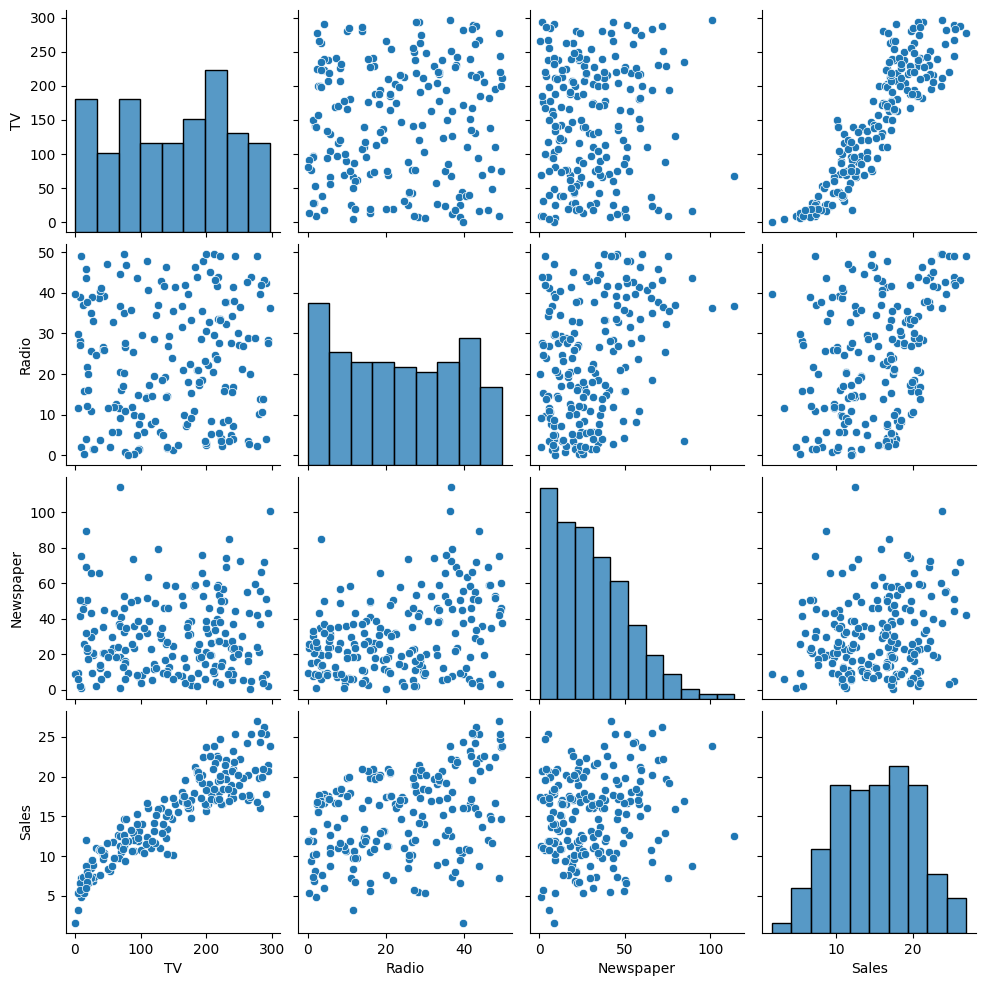

In [ ]:
sns.pairplot(df)
plt.show()

In [ ]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:5])

Predictions:
[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 1.2748262109549338
MSE: 2.9077569102710896
RMSE: 1.7052146229349223
R² Score: 0.9059011844150826


In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

     Feature  Coefficient
0         TV     0.054509
1      Radio     0.100945
2  Newspaper     0.004337


In [ ]:
new_data = pd.DataFrame({
    'TV': [200],
    'Radio': [40],
    'Newspaper': [30]
})

predicted_sales = model.predict(new_data)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 19.783894470037335


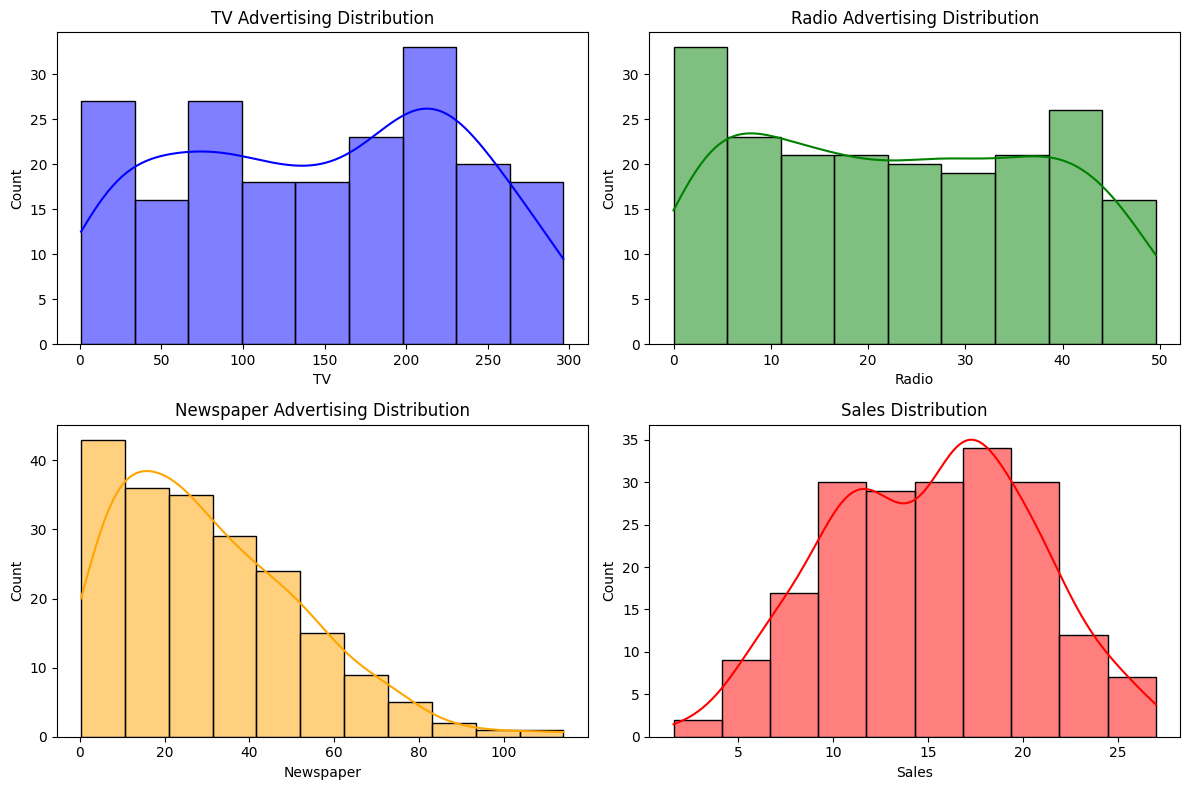

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

sns.histplot(df['TV'], kde=True, ax=axes[0,0], color='blue')
axes[0,0].set_title('TV Advertising Distribution')

sns.histplot(df['Radio'], kde=True, ax=axes[0,1], color='green')
axes[0,1].set_title('Radio Advertising Distribution')

sns.histplot(df['Newspaper'], kde=True, ax=axes[1,0], color='orange')
axes[1,0].set_title('Newspaper Advertising Distribution')

sns.histplot(df['Sales'], kde=True, ax=axes[1,1], color='red')
axes[1,1].set_title('Sales Distribution')

plt.tight_layout()
plt.show()

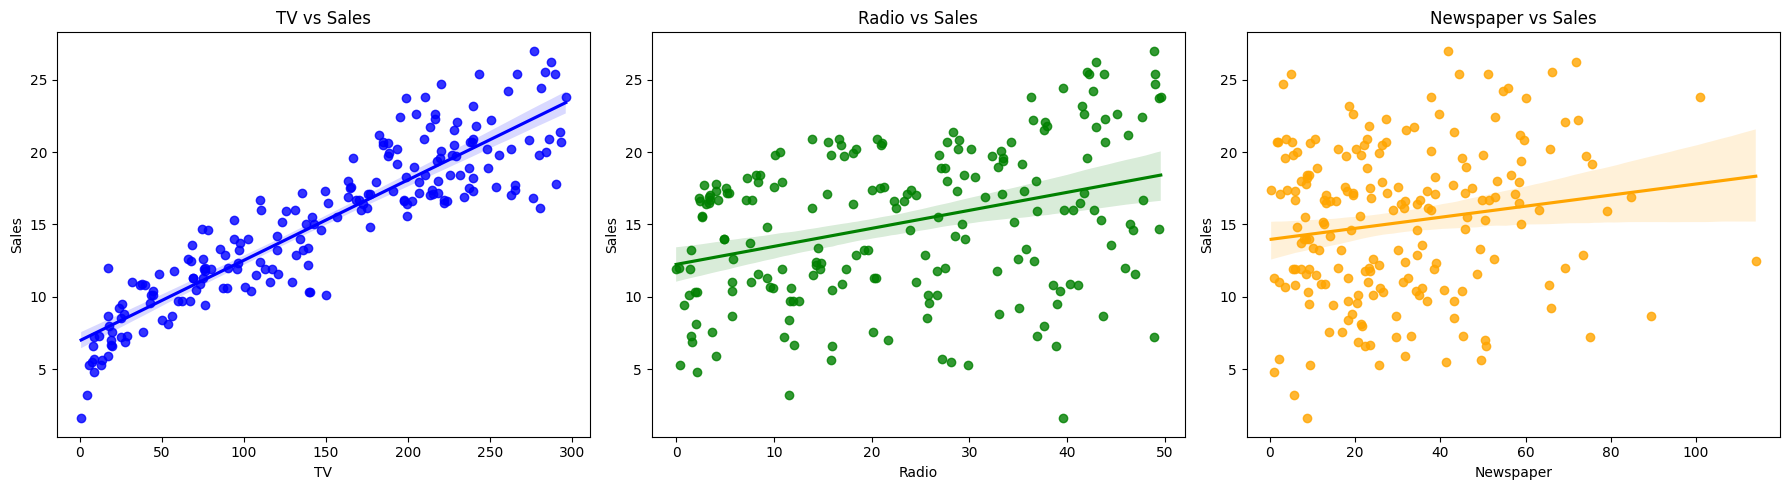

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.regplot(x='TV', y='Sales', data=df, ax=axes[0], color='blue')
axes[0].set_title('TV vs Sales')

sns.regplot(x='Radio', y='Sales', data=df, ax=axes[1], color='green')
axes[1].set_title('Radio vs Sales')

sns.regplot(x='Newspaper', y='Sales', data=df, ax=axes[2], color='orange')
axes[2].set_title('Newspaper vs Sales')

plt.tight_layout()
plt.show()

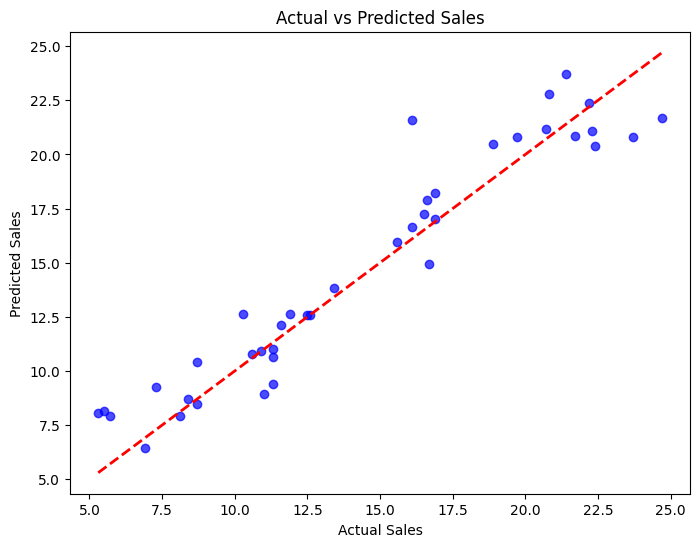

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color='blue', alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2
)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

plt.show()

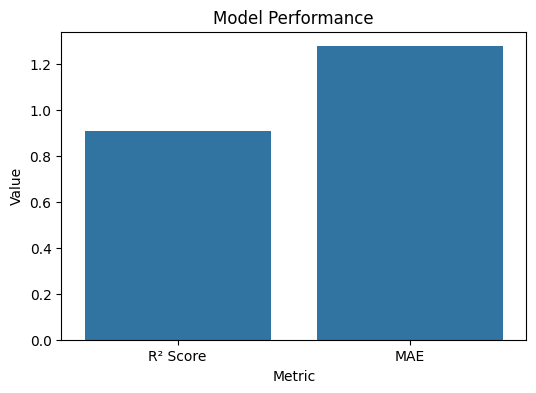

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

metrics = pd.DataFrame({
    'Metric':['R² Score','MAE'],
    'Value':[r2_score(y_test,y_pred),
             mean_absolute_error(y_test,y_pred)]
})

plt.figure(figsize=(6,4))
sns.barplot(x='Metric', y='Value', data=metrics)

plt.title('Model Performance')
plt.show()

In [ ]:
df['Sales_Category'] = pd.cut(
    df['Sales'],
    bins=[0,10,20,30],
    labels=['Low','Medium','High']
)

print(df['Sales_Category'].value_counts())

Sales_Category
Medium    127
High       39
Low        34
Name: count, dtype: int64
